# Bigram Language Model — Clean Implementation

A complete, self-contained rewrite of the bigram model with:
- All configuration in one place
- No global state leaking into classes
- Validation loss during training
- Evaluation against the known ground-truth distribution

## Imports and config

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt

# --- Hyperparameters ---
BATCH_SIZE   = 32
BLOCK_SIZE   = 8
LEARNING_RATE = 1e-3
TRAIN_STEPS  = 10_000
DATA_SIZE    = 100_000
TRAIN_SPLIT  = 0.9
SEED         = 1337

torch.manual_seed(SEED)
np.random.seed(SEED)

## Data generation

Every character is `'a'`, followed by a next character drawn from:

| next | probability |
|------|-------------|
| b    | 50%         |
| c    | 20%         |
| d    | 10%         |
| e–z  | 20% (uniform) |

Training the model on this data should cause it to learn (approximately)
the row for `'a'` in the embedding table.

In [2]:
def generate_special_pattern(size: int) -> str:
    chars: list[str] = []
    while len(chars) < size - 1:
        chars.append('a')
        r = np.random.rand()
        if r <= 0.50:
            chars.append('b')
        elif r <= 0.70:
            chars.append('c')
        elif r <= 0.80:
            chars.append('d')
        else:
            chars.append(chr(np.random.randint(ord('e'), ord('z') + 1)))
    if len(chars) < size:
        chars.append(chr(np.random.randint(ord('b'), ord('z') + 1)))
    return ''.join(chars)


text = generate_special_pattern(DATA_SIZE)
n_a = text.count('a')
print(text[:100])
print(f"ab: {text.count('ab') / n_a:.1%}  (target 50%)")
print(f"ac: {text.count('ac') / n_a:.1%}  (target 20%)")
print(f"ad: {text.count('ad') / n_a:.1%}  (target 10%)")
print(f"ae: {text.count('ae') / n_a:.1%}  (target ~1%)")

abababababacabafakacabafaxadababacadababacababababacahaoamacabadaiababacaqababadabadabauacabazaxabaj
ab: 50.0%  (target 50%)
ac: 19.8%  (target 20%)
ad: 10.0%  (target 10%)
ae: 0.9%  (target ~1%)


## Vocabulary

Maps between characters and integer indices.
Built from the unique characters that actually appear in the data.

In [3]:
class Vocabulary:
    def __init__(self, data: str):
        chars = sorted(set(data))
        self.stoi = {c: i for i, c in enumerate(chars)}
        self.itos = {i: c for i, c in enumerate(chars)}

    def encode(self, text: str) -> list[int]:
        return [self.stoi[c] for c in text]

    def decode(self, tokens: list[int]) -> str:
        return ''.join(self.itos[t] for t in tokens)

    def __len__(self) -> int:
        return len(self.stoi)


vocab = Vocabulary(text)
print(f"Vocabulary size: {len(vocab)}")
print(f"Characters: {''.join(vocab.stoi)}")

Vocabulary size: 26
Characters: abcdefghijklmnopqrstuvwxyz


## Dataset and batching

`get_batch` samples `BATCH_SIZE` random windows of length `BLOCK_SIZE`.
Each window position `t` is a training example: predict `x[t+1]` from `x[t]`.

In [4]:
data = torch.tensor(vocab.encode(text), dtype=torch.long)
n = int(TRAIN_SPLIT * len(data))
train_data, val_data = data[:n], data[n:]


def get_batch(split: str) -> tuple[torch.Tensor, torch.Tensor]:
    src = train_data if split == 'train' else val_data
    ix = torch.randint(len(src) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([src[i:i + BLOCK_SIZE]         for i in ix])
    y = torch.stack([src[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x, y

## Model

A single `nn.Embedding(vocab_size, vocab_size)` table.  
Row `i` is a vector of logits: the un-normalised score for each possible next token
given that the current token is `i`.  
No information from tokens before the current one is used — this is purely a *bigram* model.

In [5]:
class BigramModel(nn.Module):
    def __init__(self, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, vocab_size)

    def forward(
        self,
        idx: torch.Tensor,
        targets: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        logits = self.embedding(idx)  # (B, T, vocab_size)
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            probs = F.softmax(logits[:, -1, :], dim=-1)  # (B, vocab_size)
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx


model = BigramModel(len(vocab))

xb, yb = get_batch('train')
logits, loss = model(xb, yb)
random_baseline = -np.log(1 / len(vocab))
print(f"logits shape:    {logits.shape}")
print(f"initial loss:    {loss.item():.4f}  (random baseline: {random_baseline:.4f})")

logits shape:    torch.Size([32, 8, 26])
initial loss:    4.2602  (random baseline: 3.2581)


## Training

AdamW with a fixed learning rate; print both train and validation loss at the end.

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

for step in range(TRAIN_STEPS):
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

xb_val, yb_val = get_batch('val')
_, val_loss = model(xb_val, yb_val)
print(f"train loss: {loss.item():.4f}")
print(f"val   loss: {val_loss.item():.4f}")

train loss: 0.9267
val   loss: 0.9245


## Evaluation

Generate 2 000 tokens and check whether the bigram frequencies match
the data-generating distribution.

In [7]:
start   = torch.zeros((1, 1), dtype=torch.long)
tokens  = model.generate(start, max_new_tokens=2000)[0].tolist()
output  = vocab.decode(tokens)

print(output[:100])
n_a = output.count('a') or 1
print(f"ab: {output.count('ab') / n_a:.1%}  (target 50%)")
print(f"ac: {output.count('ac') / n_a:.1%}  (target 20%)")
print(f"ad: {output.count('ad') / n_a:.1%}  (target 10%)")
print(f"ae: {output.count('ae') / n_a:.1%}  (target ~1%)")

ababacabacabahabacadabacapababauabacabauabapacabamacabahadadadlaracababamadabababatauabacadabababada
ab: 47.8%  (target 50%)
ac: 20.8%  (target 20%)
ad: 11.7%  (target 10%)
ae: 0.7%  (target ~1%)


## Learned distribution for 'a'

Row 0 of the embedding table is the logit vector for token `'a'`.
After softmax it should approximate the ground-truth probabilities above.

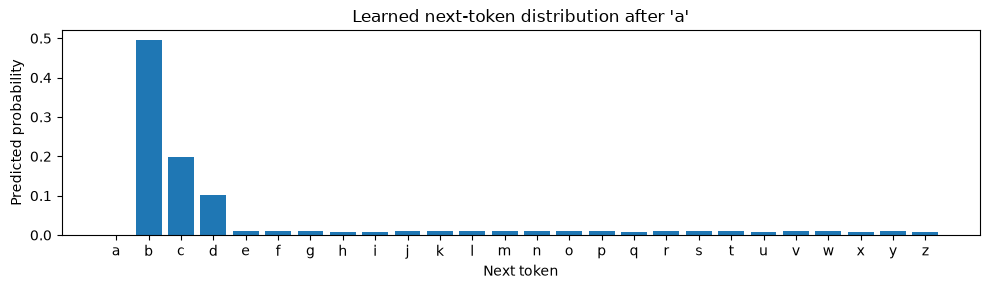

In [8]:
a_idx  = vocab.stoi['a']
w_a    = model.embedding.weight.data[a_idx]
probs  = F.softmax(w_a, dim=-1).cpu().numpy()
labels = list(vocab.stoi.keys())

plt.figure(figsize=(10, 3))
plt.bar(range(len(probs)), probs)
plt.xticks(range(len(labels)), labels)
plt.xlabel("Next token")
plt.ylabel("Predicted probability")
plt.title("Learned next-token distribution after 'a'")
plt.tight_layout()
plt.show()